### Company Comparables Valuation


by Aarav Singh

#### Import necessary libraries

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np 
import matplotlib.pyplot as plt

#### Target and Peer Companies

In [2]:
# Target company
TARGET_TICKER = input(
    "\nEnter Target Company Ticker: "
).upper()

In [3]:
# Peer companies
peer_input = input(
    "\nEnter Peer Company Tickers "
    "(comma separated): "
)

# Convert input string to list
PEERS = [

    peer.strip().upper()

    for peer in peer_input.split(",")

    if peer.strip() != ""
]

#### Fetch Financial Data

In [4]:
def fetch_financial_data(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info

    market_cap = info.get("marketCap", np.nan)
    enterprise_value = info.get("enterpriseValue", np.nan)
    revenue = info.get("totalRevenue", np.nan)
    ebitda = info.get("ebitda", np.nan)
    net_income = info.get("netIncomeToCommon", np.nan)
    pe_ratio = info.get("trailingPE", np.nan)
    debt = info.get("totalDebt", 0)
    cash = info.get("totalCash", 0)
    shares_outstanding = info.get("sharesOutstanding", np.nan)
    current_price = info.get("currentPrice", np.nan)

    ev_ebitda = enterprise_value / ebitda if ebitda not in [0, None] else np.nan
    ev_revenue = enterprise_value / revenue if revenue not in [0, None] else np.nan

    return {
        "Ticker": ticker,
        "Market Cap": market_cap,
        "Enterprise Value": enterprise_value,
        "Revenue": revenue,
        "EBITDA": ebitda,
        "Net Income": net_income,
        "P/E": pe_ratio,
        "EV/EBITDA": ev_ebitda,
        "EV/Revenue": ev_revenue,
        "Debt": debt,
        "Cash": cash,
        "Shares Outstanding": shares_outstanding,
        "Current Price": current_price
    }


In [ ]:
# Fetch peer data

peer_data = []

for peer in PEERS:
    try:
        data = fetch_financial_data(peer)
        peer_data.append(data)
        print(f"Fetched data for {peer}")
    except Exception as e:
        print(f"Error fetching {peer}: {e}")

peers_df = pd.DataFrame(peer_data)

# Display comparable company table
print("\n=== Comparable Companies Table ===")
print(peers_df[[
    "Ticker",
    "EV/EBITDA",
    "EV/Revenue",
    "P/E"
]])

Fetched data for HINDPETRO.NS
Fetched data for BPCL.NS
Fetched data for IOC.NS

=== Comparable Companies Table ===
         Ticker  EV/EBITDA  EV/Revenue       P/E
0  HINDPETRO.NS   5.166641    0.325247  5.347519
1       BPCL.NS   4.326398    0.368332  5.257902
2        IOC.NS   4.848188    0.438303  5.573575


In [ ]:
# Median multiples

median_ev_ebitda = peers_df["EV/EBITDA"].median()
median_ev_revenue = peers_df["EV/Revenue"].median()
median_pe = peers_df["P/E"].median()

print("\n=== Median Multiples ===")
print(f"Median EV/EBITDA: {median_ev_ebitda:.2f}")
print(f"Median EV/Revenue: {median_ev_revenue:.2f}")
print(f"Median P/E: {median_pe:.2f}")



=== Median Multiples ===
Median EV/EBITDA: 4.85
Median EV/Revenue: 0.37
Median P/E: 5.35


In [8]:
# Fetch target company data
target = fetch_financial_data(TARGET_TICKER)

In [10]:
# Implied Enterprise Value using EV/EBITDA
implied_ev = target["EBITDA"] * median_ev_ebitda

In [11]:
# Implied Equity Value
implied_equity_value = implied_ev - target["Debt"] + target["Cash"]

In [12]:
# Implied Share Price
implied_share_price = implied_equity_value / target["Shares Outstanding"]

#### Final Output and Visualisation

In [15]:
print("\n=== Target Company Valuation ===")
print(f"Target Company: {TARGET_TICKER}")
print(f"Current Share Price: ${target['Current Price']:.2f}")
print(f"Implied Enterprise Value: ${implied_ev:,.0f}")
print(f"Implied Equity Value: ${implied_equity_value:,.0f}")
print(f"Implied Share Price: ${implied_share_price:.2f}")


=== Target Company Valuation ===
Target Company: RELIANCE.NS
Current Share Price: $1435.20
Implied Enterprise Value: $8,675,783,792,196
Implied Equity Value: $7,129,863,738,948
Implied Share Price: $526.87


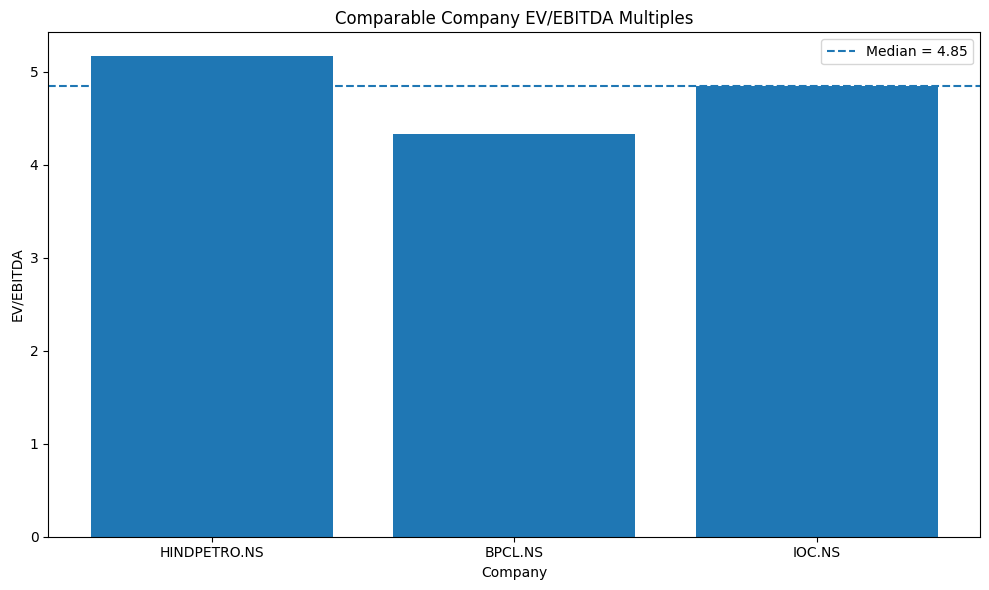

In [16]:
# Visualization
plt.figure(figsize=(10, 6))
plt.bar(peers_df["Ticker"], peers_df["EV/EBITDA"])
plt.axhline(
    median_ev_ebitda,
    linestyle='--',
    label=f'Median = {median_ev_ebitda:.2f}'
)

plt.title("Comparable Company EV/EBITDA Multiples")
plt.xlabel("Company")
plt.ylabel("EV/EBITDA")
plt.legend()

plt.tight_layout()
plt.savefig("ev_ebitda_chart.png")
plt.show()
